In [11]:
# Import library yang dibutuhkan
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [12]:
# 1. Import dan eksplorasi awal dataset
# Load dataset
df = pd.read_csv('AB_NYC_2019.csv')  # Ganti dengan path file Anda setelah download dari Kaggle

# Tampilkan informasi struktur dataset
print("Informasi Struktur Dataset:")
print(df.info())
print("\nStatistik Deskriptif:")
print(df.describe())

# Tampilkan 5 baris pertama
print("\n5 Baris Pertama Dataset:")
print(df.head())

Informasi Struktur Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  object 
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  object 
 4   neighbourhood_group             48895 non-null  object 
 5   neighbourhood                   48895 non-null  object 
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  object 
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last

In [13]:
# 2. Identifikasi dan tangani Missing Values
print("\nJumlah Missing Values per Kolom:")
print(df.isnull().sum())

# Tangani missing values tanpa inplace=True
df['name'] = df['name'].fillna('Unknown')
df['host_name'] = df['host_name'].fillna('Unknown')
df['last_review'] = df['last_review'].fillna('No Review')
df['reviews_per_month'] = df['reviews_per_month'].fillna(0)

print("\nMissing Values setelah Penanganan:")
print(df.isnull().sum())


Jumlah Missing Values per Kolom:
id                                    0
name                                 16
host_id                               0
host_name                            21
neighbourhood_group                   0
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                                 0
minimum_nights                        0
number_of_reviews                     0
last_review                       10052
reviews_per_month                 10052
calculated_host_listings_count        0
availability_365                      0
dtype: int64

Missing Values setelah Penanganan:
id                                0
name                              0
host_id                           0
host_name                         0
neighbourhood_group               0
neighbourhood                     0
latitude                          0
longitude                

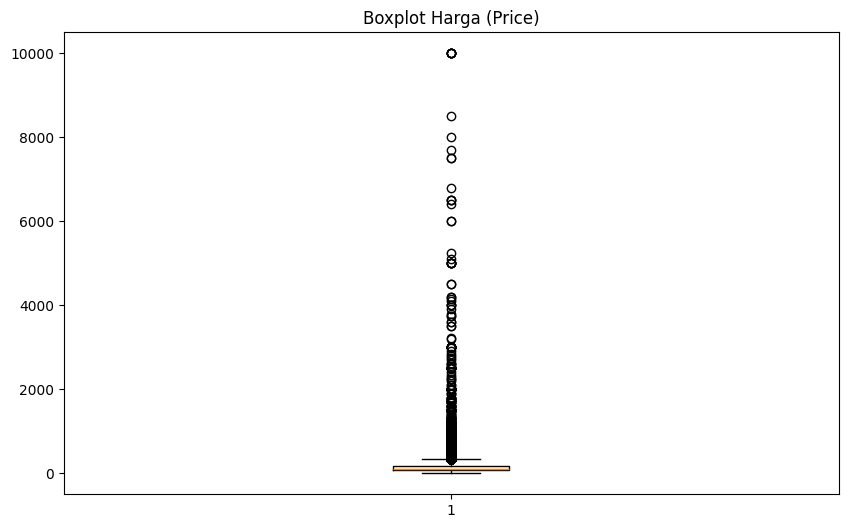


Jumlah baris setelah menghapus outliers: 45923 (sebelumnya: 48895)


In [14]:
# 3. Identifikasi dan tangani Outliers
# Visualisasi outliers pada kolom 'price' menggunakan boxplot
plt.figure(figsize=(10, 6))
plt.boxplot(df['price'].dropna())
plt.title('Boxplot Harga (Price)')
plt.show()

# Tangani outliers pada 'price' menggunakan metode IQR
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Filter data untuk menghapus outliers
df_cleaned = df[(df['price'] >= lower_bound) & (df['price'] <= upper_bound)]
print(f"\nJumlah baris setelah menghapus outliers: {df_cleaned.shape[0]} (sebelumnya: {df.shape[0]})")

In [15]:
# 4. Identifikasi dan tangani Noise
noise_price = df_cleaned[df_cleaned['price'] <= 0]
print("\nData dengan Harga <= 0 (Noise):")
print(noise_price)

# Hapus noise (harga <= 0)
df_cleaned = df_cleaned[df_cleaned['price'] > 0]


Data dengan Harga <= 0 (Noise):
             id                                               name    host_id  \
23161  18750597  Huge Brooklyn Brownstone Living, Close to it all.    8993084   
25433  20333471      ★Hostel Style Room | Ideal Traveling Buddies★  131697576   
25634  20523843    MARTIAL LOFT 3: REDEMPTION (upstairs, 2nd room)   15787004   
25753  20608117                    Sunny, Quiet Room in Greenpoint    1641537   
25778  20624541      Modern apartment in the heart of Williamsburg   10132166   
25794  20639628  Spacious comfortable master bedroom with nice ...   86327101   
25795  20639792  Contemporary bedroom in brownstone with nice view   86327101   
25796  20639914       Cozy yet spacious private brownstone bedroom   86327101   
26259  20933849                              the best you can find   13709292   
26841  21291569  Coliving in Brooklyn! Modern design / Shared room  101970559   
26866  21304320             Best Coliving space ever! Shared room.  10197055

In [16]:
# 5. Identifikasi dan tangani Data Duplicates
print("\nJumlah Duplikat:")
print(df_cleaned.duplicated().sum())

# Hapus duplikat tanpa inplace=True
df_cleaned = df_cleaned.drop_duplicates()
print(f"Jumlah baris setelah menghapus duplikat: {df_cleaned.shape[0]}")


Jumlah Duplikat:
0
Jumlah baris setelah menghapus duplikat: 45912


In [17]:
# 6. Integrasi dan Koreksi
# Simulasi dataset kedua (data transaksi sederhana)
data_transaksi = pd.DataFrame({
    'listing_id': df_cleaned['id'].head(5),
    'transaction_date': ['2023-01-01', '2023-02-01', '2023-03-01', '2023-04-01', '2023-05-01'],
    'amount': [100, 150, 200, 120, 180]
})

# Gabungkan dataset
df_integrated = pd.merge(df_cleaned, data_transaksi, left_on='id', right_on='listing_id', how='left')
print("\nDataset Setelah Integrasi:")
print(df_integrated.head())

# Tangani inkonsistensi format tanggal pada 'last_review'
df_integrated['last_review'] = pd.to_datetime(df_integrated['last_review'], errors='coerce', format='%Y-%m-%d')
print("\nFormat Tanggal Setelah Koreksi:")
print(df_integrated['last_review'].head())


Dataset Setelah Integrasi:
     id                                              name  host_id  \
0  2539                Clean & quiet apt home by the park     2787   
1  2595                             Skylit Midtown Castle     2845   
2  3647               THE VILLAGE OF HARLEM....NEW YORK !     4632   
3  3831                   Cozy Entire Floor of Brownstone     4869   
4  5022  Entire Apt: Spacious Studio/Loft by central park     7192   

     host_name neighbourhood_group neighbourhood  latitude  longitude  \
0         John            Brooklyn    Kensington  40.64749  -73.97237   
1     Jennifer           Manhattan       Midtown  40.75362  -73.98377   
2    Elisabeth           Manhattan        Harlem  40.80902  -73.94190   
3  LisaRoxanne            Brooklyn  Clinton Hill  40.68514  -73.95976   
4        Laura           Manhattan   East Harlem  40.79851  -73.94399   

         room_type  price  minimum_nights  number_of_reviews last_review  \
0     Private room    149           

In [18]:
# Simpan dataset yang sudah dibersihkan
df_integrated.to_csv('cleaned_nyc_airbnb.csv', index=False)
print("\nDataset telah disimpan sebagai 'cleaned_nyc_airbnb.csv'")


Dataset telah disimpan sebagai 'cleaned_nyc_airbnb.csv'
